# NLP-Based Sentiment and Text Analysis of Gaming Platform Reviews

## Objective

User reviews and summaries from a gaming platform were analyed in order to understand customer sentiment, identify key themes through word frequency  and compare emotional tone differences between detailed reviews and condensed summaries. The aim is to translate insights from user sentiment into actionable business decisions that enhance the gaming experience.

## Approach
✔ Collected review and summary text data from the gaming platform dataset.
✔ Cleaned and preprocessed text (lowercasing, removing punctuation, stopwords).
✔ Tokenised text and performed lemmatisation for standardisation.
✔ Conducted word frequency analysis and generated word clouds for:
            ### Reviews
            ### Summaries
            ### Combined dataset
✔ Applied sentiment analysis using polarity scoring to classify:Positive,Neutral,Negative.
✔ Compared sentiment distribution between reviews and summaries.

## Key Insights

✔ Overall, the feedback is positive, indicating a generally favourable sentiment across the dataset, although sentiment levels are mostly mildly positive.
✔ Negative opinions are present but remain a smaller proportion, reviews showing a slightly higher level of negativity.
✔ Summaries exhibit a higher proportion of neutral sentiment, suggesting they tend to be more balanced and less emotionally expressive than full reviews.
✔ Reviews are more emotionally expressive, while summaries tend to be more neutral and condensed in tone.
✔ Presence of extreme positive and negative cases.

🔑 Word Frequency Insights
Reviews (Top words)
game (1941)
great (596)
one (572)
fun (553)
play (542)

👉 Indicates strong focus on gameplay experience and enjoyment.

Summaries (Top words)
star (478)
five (381)
game (334)
great (295)
fun (218)
love (114)

👉 Indicates rating-based summarisation and positive sentiment emphasis.

Combined Top Words
star (478)
five (381)
game (334)
great (295)
fun (218)
love (114)

👉 Shows overall satisfaction and rating-driven feedback patterns.

## Conclusion:
✔ The gaming platform receives highly positive user feedback, indicating high overall satisfaction.
✔ Reviews are more detailed and emotionally expressive while summaries are more structured and neutral.
✔ Keyword analysis shows strong emphasis on gameplay experience, enjoyment, and rating-based expressions.
✔ Sentiment analysis indicates a strong positive bias in user feedback, with relatively low levels of negative sentiment compared to positive and neutral responses.
✔ The dataset suggests users generally enjoy the platform, with engagement driven by fun gameplay and overall experience quality.

## Information loss in summarisation
The analysis indicates that the summaries in the dataset are shorter than the corresponding review texts, suggesting strong text reduction. Low lexical overlap further indicates limited reuse of exact wording between the two, reflecting a high degree of rephrasing.

✔ In summaries, some sentiment information is reduced due to compression/rephrasing of the original text, leading to more neutral and less emotionally expressive outputs. Therefore, analysing original reviews provides a richer and more accurate representation of user sentiment.

## Marginal customers identified in K-Means Clustering
✔ Around 400 customers fall into the marginal clusters, indicating they are relatively indifferent with no strong positive or negative sentiment.                                           

# Business Actions by Customer Sentiment Segment
## Overall Business Insight
✔ Use sentiment to guide customer targeting strategy.
✔ Improve retention, engagement, and satisfaction.
✔ Reduce churn by addressing negative experiences early.

## Positive Customers
✔ Reward loyalty (bonuses, perks, exclusive content).
✔ Encourage reviews and referrals.
✔ Offer early access to new features.
✔ Build brand ambassadors.

## Neutral Customers
✔ Personalised recommendations.
✔ Improve onboarding experience.
✔ Highlight popular features/content.
✔ Use targeted promotions and notifications.

## Negative Customers
✔ Focus on recovering brand reputation and improving overall user experience.
✔ Collect feedback (surveys, support tickets).
✔ Address pain points (bugs, UX issues).
✔ Offer compensation or incentives.
✔ Make improments based on complaints.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data
data = pd.read_csv(r"C:\Users\lakma\Documents\kaggal_data\turtle_reviews.csv")

data.head(5)

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [3]:
# make copy
df = data.copy()

In [4]:
df.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'language', 'platform', 'product',
       'review', 'summary'],
      dtype='object')

In [8]:
df.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [5]:
df.info

<bound method DataFrame.info of       gender  age  remuneration (k£)  spending_score (1-100)  loyalty_points  \
0       Male   18              12.30                      39             210   
1       Male   23              12.30                      81             524   
2     Female   22              13.12                       6              40   
3     Female   25              13.12                      77             562   
4     Female   33              13.94                      40             366   
...      ...  ...                ...                     ...             ...   
1995  Female   37              84.46                      69            4031   
1996  Female   43              92.66                       8             539   
1997    Male   34              92.66                      91            5614   
1998    Male   34              98.40                      16            1048   
1999    Male   32              92.66                       8             479   

     ed

In [6]:
# check for duplicates
df.duplicated().sum()

0

In [7]:
# extracting a subset of text data
df1=df[['review','summary']]

### NLP Processing Pipeline
1. Text cleaning (lowercasing, removing punctuation, URLs, and noise)
2. Tokenisation (splitting text into words)
3. Stopword and domain-specific word removal
4. Lemmatization for word normalisation
5. Word frequency analysis (optionally TF-IDF weighting)
6. Word cloud generation for visualisation

# Analysis of reviews

In [8]:
# clean reviews: lowercase, remove punctuations, URLs 
import re

# Text cleaning function
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# Apply cleaning to the REVIEW column 
df1["clean_review"] = df1["review"].apply(clean_text)

# View result
print(df1[["review", "clean_review"]])

                                                 review  \
0     When it comes to a DM's screen, the space on t...   
1     An Open Letter to GaleForce9*:\n\nYour unpaint...   
2     Nice art, nice printing.  Why two panels are f...   
3     Amazing buy! Bought it as a gift for our new d...   
4     As my review of GF9's previous screens these w...   
...                                                 ...   
1995  The perfect word game for mixed ages (with Mom...   
1996  Great game.  Did not think I would like it whe...   
1997  Great game for all.........\nKeeps the mind ni...   
1998                                          fun game!   
1999  This game is fun. A lot like scrabble without ...   

                                           clean_review  
0     when it comes to a dms screen the space on the...  
1     an open letter to galeforce your unpainted min...  
2     nice art nice printing why two panels are fill...  
3     amazing buy bought it as a gift for our new dm...  
4

In [9]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download required resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialise tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# Apply NLP pipeline to dataset


all_tokens = []

for text in df1["clean_review"]:
    
    # 2. Tokenisation
    tokens = word_tokenize(text)

    # 3. Stopword removal
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]

    # 4. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    all_tokens.extend(tokens)

# 5. Word frequency analysis
word_freq = Counter(all_tokens)
# Show top words
print(word_freq.most_common(10))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lakma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lakma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lakma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[('game', 1941), ('great', 596), ('one', 572), ('fun', 553), ('play', 542), ('love', 477), ('like', 434), ('card', 431), ('tile', 400), ('get', 369)]


In [11]:
# Convert to DataFrame (optional)
freq_df = pd.DataFrame(word_freq .items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False)

print(freq_df.head(10))


       word  frequency
40     game       1941
38    great        596
94      one        572
375     fun        553
308    play        542
180    love        477
195    like        434
37     card        431
2733   tile        400
285     get        369


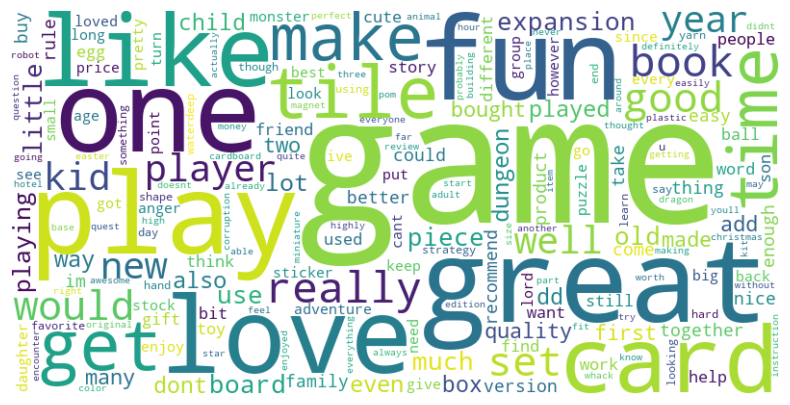

In [12]:
# Convert back to dictionary for WordCloud
freq_dict = dict(zip(freq_df["word"], freq_df["frequency"]))

# Word cloud generation
wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(freq_dict)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Analysis of summary

In [61]:
# clean summary: lowercase, remove punctuations, URLs 
import re

# Text cleaning function
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# Apply cleaning to the REVIEW column 
df1["clean_summary"] = df1["summary"].apply(clean_text)

# View result
print(df1[["summary", "clean_summary"]])

                                                summary  \
0     The fact that 50% of this space is wasted on a...   
1     Another worthless Dungeon Master's screen from...   
2                       pretty, but also pretty useless   
3                                            Five Stars   
4                                            Money trap   
...                                                 ...   
1995     The perfect word game for mixed ages (with Mom   
1996                                          Super fun   
1997                                         Great Game   
1998                                         Four Stars   
1999                                     Love this game   

                                          clean_summary  
0     the fact that of this space is wasted on art a...  
1     another worthless dungeon masters screen from ...  
2                        pretty but also pretty useless  
3                                            five stars  
4

In [14]:
# Apply NLP pipeline to summary


all_tokens = []

for text in df1["clean_summary"]:
    
    # 2. Tokenisation
    tokens = word_tokenize(text)

    # 3. Stopword removal
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]

    # 4. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    all_tokens.extend(tokens)

# 5. Word frequency analysis
word_freq = Counter(all_tokens)
# Show top words
print(word_freq.most_common(10))

[('star', 478), ('five', 381), ('game', 334), ('great', 295), ('fun', 218), ('love', 114), ('good', 92), ('expansion', 61), ('four', 58), ('like', 55)]


In [15]:
# Convert to DataFrame 
freq_df1 = pd.DataFrame(word_freq .items(), columns=["word", "frequency"])
freq_df1 = freq_df.sort_values(by="frequency", ascending=False)

print(freq_df1.head(10))

       word  frequency
40     game       1941
38    great        596
94      one        572
375     fun        553
308    play        542
180    love        477
195    like        434
37     card        431
2733   tile        400
285     get        369


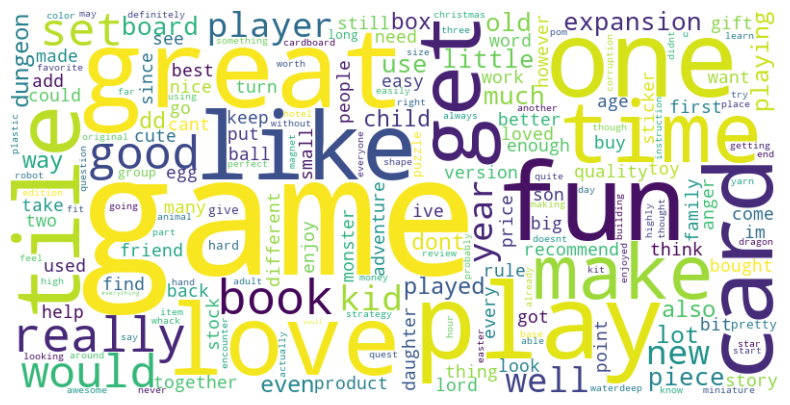

In [16]:
# Convert back to dictionary for WordCloud
freq_dict = dict(zip(freq_df1["word"], freq_df1["frequency"]))

# Word cloud generation
wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(freq_dict)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Combine reviews and summaries

In [17]:
# Create combined tokens (reviews + summaries)
combined_texts = pd.concat([df1["clean_review"], df1["clean_summary"]])
combined_texts

0       when it comes to a dms screen the space on the...
1       an open letter to galeforce your unpainted min...
2       nice art nice printing why two panels are fill...
3       amazing buy bought it as a gift for our new dm...
4       as my review of gfs previous screens these wer...
                              ...                        
1995        the perfect word game for mixed ages with mom
1996                                            super fun
1997                                           great game
1998                                           four stars
1999                                       love this game
Length: 4000, dtype: object

In [18]:
# Text Preprocessing
all_tokens = []

for text in combined_texts:
    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    all_tokens.extend(tokens)

In [20]:
# Word Frequency
from collections import Counter

word_freq = Counter(all_tokens)

In [21]:
# Covert to a dataframe
freq_df = pd.DataFrame(word_freq.items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False)

print(freq_df.head(10))

       word  frequency
40     game       2275
38    great        891
375     fun        771
94      one        615
180    love        591
308    play        570
18     star        541
195    like        489
37     card        445
2733   tile        426


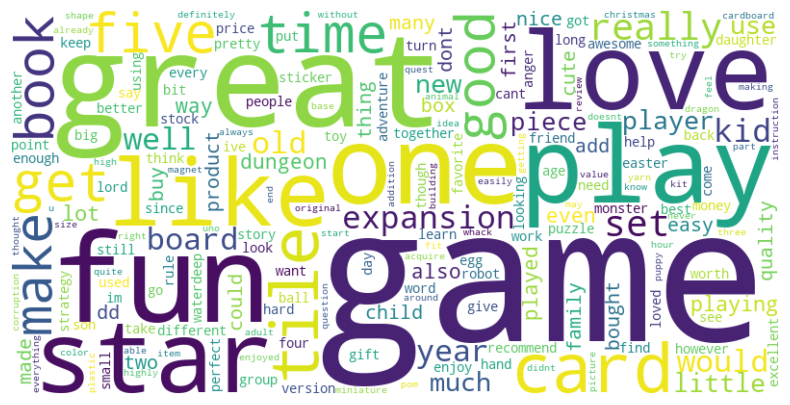

In [22]:
# generate the cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Analyse polarity and sentiment

Polarity → a score from -1 to +1
-1 =  negative
0 = neutral
+1 =  positive


In [62]:
new_df = df1[["clean_review","clean_summary"]]
new_df

,clean_review,clean_summary
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art a...
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gfs previous screens these wer...,money trap
...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom
1996,great game did not think i would like it when ...,super fun
1997,great game for all keeps the mind nimble,great game
1998,fun game,four stars


In [63]:
import pandas as pd
import re
from textblob import TextBlob
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Create working dataframe
new_df = df1[["clean_review", "clean_summary"]].copy()

# Token cleaning function
def clean_tokens(text):
    tokens = TextBlob(str(text)).words
    
    cleaned = [
        word.lower()
        for word in tokens
        if word.lower() not in stop_words and not re.search(r'\d', word)
    ]
    
    return cleaned

# Sentiment (polarity) function
def generate_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# Apply sentiment analysis
new_df["Review_Polarity"] = new_df["clean_review"].apply(generate_polarity)
new_df["Summary_Polarity"] = new_df["clean_summary"].apply(generate_polarity)

# Apply tokenisation + cleaning
new_df["Review_Tokens"] = new_df["clean_review"].apply(clean_tokens)
new_df["Summary_Tokens"] = new_df["clean_summary"].apply(clean_tokens)

# View result
print(new_df.head(10))

                                        clean_review  \
0  when it comes to a dms screen the space on the...   
1  an open letter to galeforce your unpainted min...   
2  nice art nice printing why two panels are fill...   
3  amazing buy bought it as a gift for our new dm...   
4  as my review of gfs previous screens these wer...   
5                                     grandson loves   
6  i have bought many gm screens over the years b...   
7                          came in perfect condition   
8  could be better but its still great i love the...   
9  my review will mirror others in that this kind...   

                                       clean_summary  Review_Polarity  \
0  the fact that of this space is wasted on art a...        -0.036111   
1  another worthless dungeon masters screen from ...         0.035952   
2                     pretty but also pretty useless         0.116640   
3                                         five stars         0.578788   
4                 

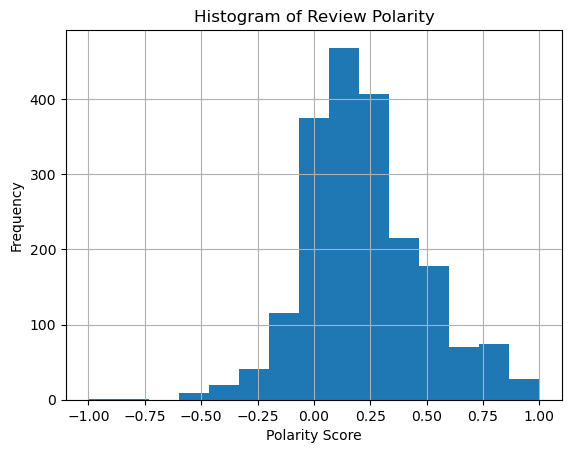

In [25]:
# Review: 
# Histogram of polarity
import matplotlib.pyplot as plt

# Create a histogram of the Review_Polarity column with 15 bins
new_df['Review_Polarity'].hist(bins=15)

plt.title('Histogram of Review Polarity')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

In [64]:
# Classify overall sentiment based on TextBlob polarity score
positive = (new_df['Review_Polarity'] > 0.05).sum()
negative = (new_df['Review_Polarity'] < -0.05).sum()
neutral = ((new_df['Review_Polarity'] >= -0.05) & (new_df['Review_Polarity'] <= 0.05)).sum()

print(f"Positive: {positive}")
print(f"Neutral: {neutral}")
print(f"Negative: {negative}")

Positive: 1486
Neutral: 287
Negative: 227


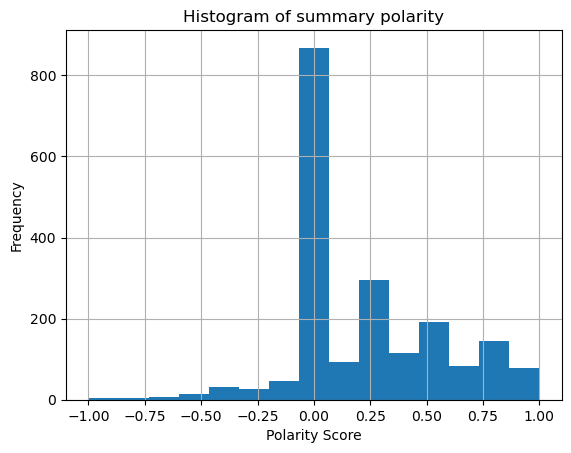

In [27]:
# summary: 
# Histogram of polarity
import matplotlib.pyplot as plt

# Create a histogram of the Review_Polarity column with 15 bins
new_df['Summary_Polarity'].hist(bins=15)

plt.title('Histogram of summary polarity')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

In [28]:
# Classify overall sentiment based on TextBlob polarity score
positive = (new_df['Summary_Polarity'] > 0.05).sum()
negative = (new_df['Summary_Polarity'] < -0.05).sum()
neutral = ((new_df['Summary_Polarity'] >= -0.05) & (new_df['Summary_Polarity'] <= 0.05)).sum()

print(f"Positive: {positive}")
print(f"Neutral: {neutral}")
print(f"Negative: {negative}")

Positive: 1011
Neutral: 821
Negative: 168


In [65]:
# Top 20 negative reviews.
top_20_negative_reviews = new_df.sort_values(by='Review_Polarity', ascending=True).head(20)

# View output
print(top_20_negative_reviews[['clean_review', 'Review_Polarity']])

                                           clean_review  Review_Polarity
208   booo unles you are patient know how to measure...        -1.000000
182                   incomplete kit very disappointing        -0.780000
1804  im sorry i just find this product to be boring...        -0.583333
364   one of my staff will be using this game soon s...        -0.550000
230                    i found the directions difficult        -0.500000
117   i bought this as a christmas gift for my grand...        -0.500000
301                                           difficult        -0.500000
1524                         expensive for what you get        -0.500000
227   this was a gift for my daughter i found it dif...        -0.500000
290              instructions are complicated to follow        -0.500000
174   i sent this product to my granddaughter the po...        -0.491667
347   my yearold granddaughter and i were very frust...        -0.446250
538   i purchased this on the recommendation of two

In [66]:
new_df

,clean_review,clean_summary,Review_Polarity,Summary_Polarity,Review_Tokens,Summary_Tokens
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art a...,-0.036111,0.150000,"[comes, dms, screen, space, screen, absolute, ...","[fact, space, wasted, art, terribly, informati..."
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,0.035952,-0.800000,"[open, letter, galeforce, unpainted, miniature...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,0.116640,0.000000,"[nice, art, nice, printing, two, panels, fille...","[pretty, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,0.578788,0.000000,"[amazing, buy, bought, gift, new, dm, perfect]","[five, stars]"
4,as my review of gfs previous screens these wer...,money trap,-0.316667,0.000000,"[review, gfs, previous, screens, completely, u...","[money, trap]"
...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,0.168750,0.200000,"[perfect, word, game, mixed, ages, mom, perhap...","[perfect, word, game, mixed, ages, mom]"
1996,great game did not think i would like it when ...,super fun,0.158333,0.316667,"[great, game, think, would, like, first, recei...","[super, fun]"
1997,great game for all keeps the mind nimble,great game,0.200000,0.200000,"[great, game, keeps, mind, nimble]","[great, game]"
1998,fun game,four stars,-0.050000,0.000000,"[fun, game]","[four, stars]"


# Top 20 negative reviews and summaries

In [67]:
# Top 20 negative summaries.
top_20_negative_reviews = new_df.sort_values(by='Summary_Polarity', ascending=True).head(20)
print(top_20_negative_reviews[['clean_summary', 'Summary_Polarity']])

                                          clean_summary  Summary_Polarity
21                        the worst value ive ever seen         -1.000000
208     boring unless you are a craft person which i am         -1.000000
829                                              boring         -1.000000
1166  before this i hated running any rpg campaign d...         -0.900000
1     another worthless dungeon masters screen from ...         -0.800000
1620                                       disappointed         -0.750000
144                                        disappointed         -0.750000
793                                        disappointed         -0.750000
631                                        disappointed         -0.750000
363   promotes anger instead of teaching calming met...         -0.700000
890                        bad qualityall made of paper         -0.700000
885            too bad this is not what i was expecting         -0.700000
178         at age i found these very 

In [91]:
new_df.describe()

,Review_Polarity,Summary_Polarity
count,2000.000000,2000.000000
mean,0.217702,0.219317
std,0.262489,0.335627
min,-1.000000,-1.000000
25%,0.049888,0.000000
50%,0.182258,0.062500
75%,0.361028,0.451250
max,1.000000,1.000000


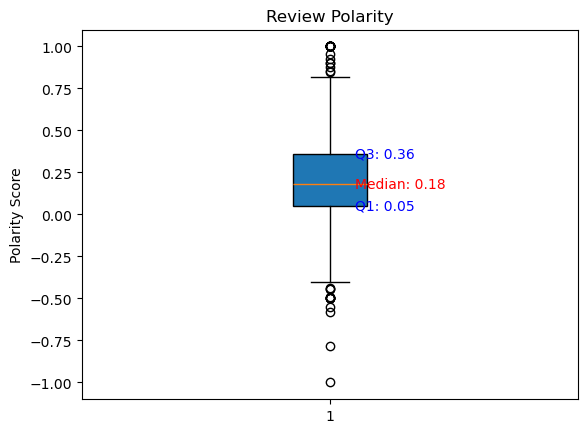

In [68]:
# Box plot to summarise stats- review_polarity score

# Use the polarity column from your DataFrame
plot = new_df['Review_Polarity'].sort_values().values

fig, ax = plt.subplots()
ax.boxplot(plot, patch_artist=True)

# Calculate quartiles and median
q1 = np.percentile(plot, 25)
median = np.percentile(plot, 50)
q3 = np.percentile(plot, 75)

# Label Q1, Median, Q3
ax.text(1.05, q1, f'Q1: {q1:.2f}', va='center', color='blue')
ax.text(1.05, median, f'Median: {median:.2f}', va='center', color='red')
ax.text(1.05, q3, f'Q3: {q3:.2f}', va='center', color='blue')

plt.title('Review Polarity')
plt.ylabel('Polarity Score')
plt.show()

In [129]:
new_df['Review_Polarity'].describe()

count    2000.000000
mean        0.217702
std         0.262489
min        -1.000000
25%         0.049888
50%         0.182258
75%         0.361028
max         1.000000
Name: Review_Polarity, dtype: float64

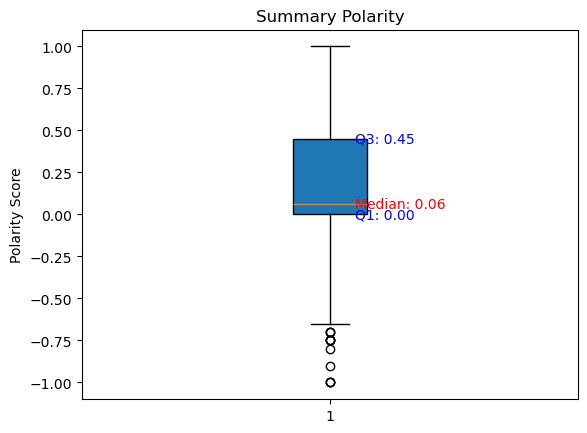

In [79]:
# Box plot to summerise stats of Summary polarity scores

# Use the polarity column
plot = new_df['Summary_Polarity'].sort_values().values

fig, ax = plt.subplots()
ax.boxplot(plot, patch_artist=True)

# Calculate quartiles and median
q1 = np.percentile(plot, 25)
median = np.percentile(plot, 50)
q3 = np.percentile(plot, 75)

# Label Q1, Median, Q3
ax.text(1.05, q1, f'Q1: {q1:.2f}', va='center', color='blue')
ax.text(1.05, median, f'Median: {median:.2f}', va='center', color='red')
ax.text(1.05, q3, f'Q3: {q3:.2f}', va='center', color='blue')

plt.title('Summary Polarity')
plt.ylabel('Polarity Score')

plt.show()

In [128]:
new_df['Summary_Polarity'].describe()

count    2000.000000
mean        0.219317
std         0.335627
min        -1.000000
25%         0.000000
50%         0.062500
75%         0.451250
max         1.000000
Name: Summary_Polarity, dtype: float64

In [69]:
new_df

,clean_review,clean_summary,Review_Polarity,Summary_Polarity,Review_Tokens,Summary_Tokens
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art a...,-0.036111,0.150000,"[comes, dms, screen, space, screen, absolute, ...","[fact, space, wasted, art, terribly, informati..."
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,0.035952,-0.800000,"[open, letter, galeforce, unpainted, miniature...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,0.116640,0.000000,"[nice, art, nice, printing, two, panels, fille...","[pretty, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,0.578788,0.000000,"[amazing, buy, bought, gift, new, dm, perfect]","[five, stars]"
4,as my review of gfs previous screens these wer...,money trap,-0.316667,0.000000,"[review, gfs, previous, screens, completely, u...","[money, trap]"
...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,0.168750,0.200000,"[perfect, word, game, mixed, ages, mom, perhap...","[perfect, word, game, mixed, ages, mom]"
1996,great game did not think i would like it when ...,super fun,0.158333,0.316667,"[great, game, think, would, like, first, recei...","[super, fun]"
1997,great game for all keeps the mind nimble,great game,0.200000,0.200000,"[great, game, keeps, mind, nimble]","[great, game]"
1998,fun game,four stars,-0.050000,0.000000,"[fun, game]","[four, stars]"


In [70]:
# Raw counts
categories = ['Positive', 'Neutral', 'Negative']
reviews = [1486, 287, 227]
summary = [1011, 821, 168]

# create a dictionary
sentiment_counts = {
    "Positive": {"reviews": 1486, "summary": 1011},
    "Neutral": {"reviews": 287, "summary": 821},
    "Negative": {"reviews": 227, "summary": 168}
}

# create a dataframe
import pandas as pd

df_sentiment = pd.DataFrame(sentiment_counts).T
print(df_sentiment)

          reviews  summary
Positive     1486     1011
Neutral       287      821
Negative      227      168


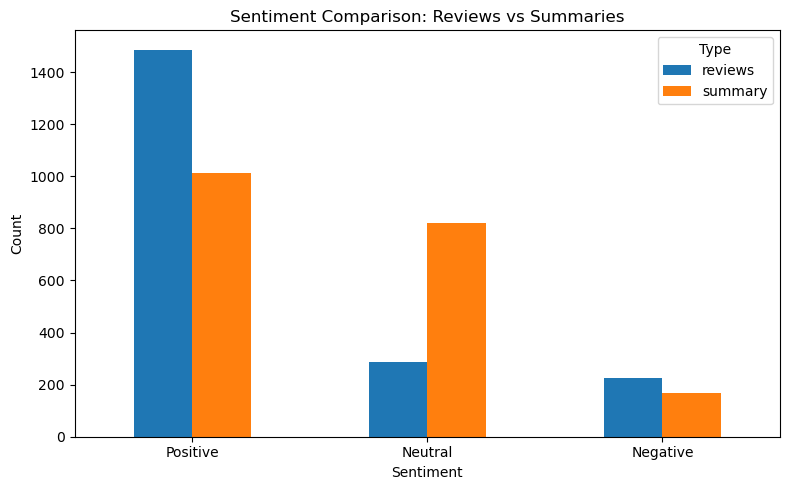

In [71]:
# comparison of reviews and summary
df_sentiment.plot(kind='bar', figsize=(8,5))

plt.title("Sentiment Comparison: Reviews vs Summaries")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Type")
plt.tight_layout()
plt.show()

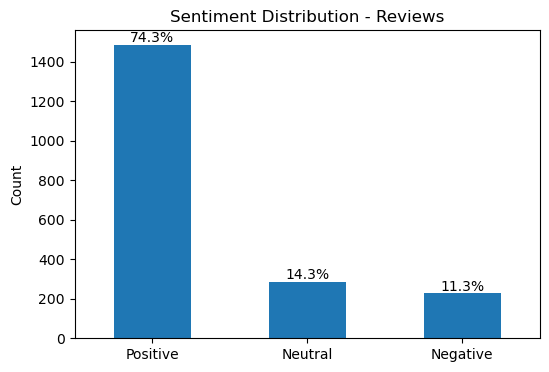

In [73]:
import matplotlib.pyplot as plt

df_reviews = df_sentiment[["reviews"]]

ax = df_reviews.plot(kind="bar", legend=False, figsize=(6,4))

plt.title("Sentiment Distribution - Reviews")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Total for percentage calculation
total = df_reviews["reviews"].sum()

# Add % labels
for p in ax.patches:
    height = p.get_height()
    percent = (height / total) * 100
    
    ax.annotate(
        f'{percent:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.show()

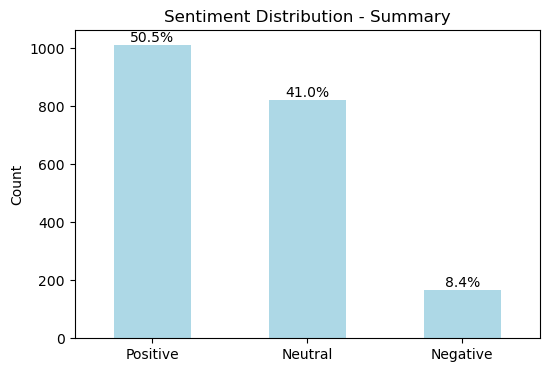

In [74]:
# with percentages annotate
df_reviews = df_sentiment[["summary"]]

ax = df_reviews.plot(kind="bar", legend=False, figsize=(6,4), color='lightblue')

plt.title("Sentiment Distribution - Summary")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Add % annotations
total = df_reviews["summary"].sum()

for p in ax.patches:
    height = p.get_height()
    percent = (height / total) * 100
    
    ax.annotate(
        f'{percent:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.show()

# Information loss in summarisation

In [ ]:
# Word overlap:
# Higher overlap = summary is closer to original
# Lower overlap = more compression / information loss

In [75]:
df1['review'][0]

"When it comes to a DM's screen, the space on the screen itself is at an absolute premium. The fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. The only reason that I gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. Other than that, it drops the ball completely."

In [76]:
df1['summary'][0]


'The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...'

In [78]:
# checking for overlapping words: 
def word_overlap(review, summary):
    review_set = set(review.split())
    summary_set = set(summary.split())
    
    if len(review_set) == 0:
        return 0
    
    return len(review_set & summary_set) / len(review_set)

df1["overlap_score"] = df1.apply(
    lambda x: word_overlap(x["clean_review"], x["clean_summary"]),
    axis=1
)

print(df1["overlap_score"].describe())

count    2000.000000
mean        0.102485
std         0.173667
min         0.000000
25%         0.000000
50%         0.035714
75%         0.110405
max         1.000000
Name: overlap_score, dtype: float64


The proportion of review words appearing in summaries is approximately 10%, indicating that summaries share very few exact words with the original reviews. The median value is even lower, suggesting that in most cases there is minimal lexical reuse between reviews and their corresponding summaries.

In [79]:
# Length reduction (compression ratio): length summary: lengthreview ratio
df1["review_len"] = df1["clean_review"].apply(lambda x: len(x.split()))
df1["summary_len"] = df1["clean_summary"].apply(lambda x: len(x.split()))

df1["compression_ratio"] = df1["summary_len"] / df1["review_len"]

print(df1["compression_ratio"].describe())

count    2000.000000
mean        0.278336
std         0.586816
min         0.002882
25%         0.062500
50%         0.148542
75%         0.333333
max        21.000000
Name: compression_ratio, dtype: float64


The mean review-to-summary length ratio is 0.28, indicating that summaries are, on average, 28% of the length of the original reviews. The median is lower than the mean, suggesting that in most cases summaries are even more highly compressed, with greater reductions in text length.

# Closer look at customers at margins of k_mean analysis. 
🔥 Why marginal cluster sentiment matters

These customers sit in the decision zone:

They’re not clearly loyal
They’re not fully churned
They’re in between

That makes them high leverage.

In [ ]:
## index number of customers who are found to be on borderline when customers were segmented based on income and spending_score.

In [80]:
new_df = new_df.reset_index(drop=True)
new_df

,clean_review,clean_summary,Review_Polarity,Summary_Polarity,Review_Tokens,Summary_Tokens
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art a...,-0.036111,0.150000,"[comes, dms, screen, space, screen, absolute, ...","[fact, space, wasted, art, terribly, informati..."
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,0.035952,-0.800000,"[open, letter, galeforce, unpainted, miniature...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,0.116640,0.000000,"[nice, art, nice, printing, two, panels, fille...","[pretty, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,0.578788,0.000000,"[amazing, buy, bought, gift, new, dm, perfect]","[five, stars]"
4,as my review of gfs previous screens these wer...,money trap,-0.316667,0.000000,"[review, gfs, previous, screens, completely, u...","[money, trap]"
...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,0.168750,0.200000,"[perfect, word, game, mixed, ages, mom, perhap...","[perfect, word, game, mixed, ages, mom]"
1996,great game did not think i would like it when ...,super fun,0.158333,0.316667,"[great, game, think, would, like, first, recei...","[super, fun]"
1997,great game for all keeps the mind nimble,great game,0.200000,0.200000,"[great, game, keeps, mind, nimble]","[great, game]"
1998,fun game,four stars,-0.050000,0.000000,"[fun, game]","[four, stars]"


In [81]:
new_df.columns

Index(['clean_review', 'clean_summary', 'Review_Polarity', 'Summary_Polarity',
       'Review_Tokens', 'Summary_Tokens'],
      dtype='object')

## Filter the 400 marginal customers from KMeans clustering. dataset does not contain customer ID, there for Index number used as the ID. Following list obtained from "Customer Loyalty Analysis: Drivers and Customer Segmentation".

In [127]:
# index list of 400 customer 
idx_list = [
    6, 14, 16, 20, 26, 28, 36, 38, 55, 66,
    76, 77, 81, 83, 88, 92, 93, 94, 96, 98,
    112, 117, 119, 120, 121, 122, 124, 126, 128,
    132, 133, 140, 142, 146, 160, 176, 178, 206,
    214, 216, 220, 226, 228, 236, 238, 255, 266,
    276, 277, 281, 283, 288, 292, 293, 294, 296,
    298, 312, 317, 319, 320, 321, 322, 324, 326,
    328, 332, 333, 340, 342, 346, 360, 376, 378,
    406, 414, 416, 420, 426, 428, 436, 438, 455,
    466, 476, 477, 481, 483, 488, 492, 493, 494,
    496, 498, 512, 517, 519, 520, 521, 522, 524,
    526, 528, 532, 533, 540, 542, 546, 560, 576,
    578, 606, 614, 616, 620, 626, 628, 636, 638,
    655, 666, 676, 677, 681, 683, 688, 692, 693,
    694, 696, 698, 712, 717, 719, 720, 721, 722,
    724, 726, 728, 732, 733, 740, 742, 746, 760,
    776, 778, 806, 814, 816, 820, 826, 828, 836,
    838, 855, 866, 876, 877, 881, 883, 888, 892,
    893, 894, 896, 898, 912, 917, 919, 920, 921,
    922, 924, 926, 928, 932, 933, 940, 942, 946,
    960, 976, 978, 1006, 1014, 1016, 1020, 1026,
    1028, 1036, 1038, 1055, 1066, 1076, 1077, 1081,
    1083, 1088, 1092, 1093, 1094, 1096, 1098, 1112,
    1117, 1119, 1120, 1121, 1122, 1124, 1126, 1128,
    1132, 1133, 1140, 1142, 1146, 1160, 1176, 1178,
    1206, 1214, 1216, 1220, 1226, 1228, 1236, 1238,
    1255, 1266, 1276, 1277, 1281, 1283, 1288, 1292,
    1293, 1294, 1296, 1298, 1312, 1317, 1319, 1320,
    1321, 1322, 1324, 1326, 1328, 1332, 1333, 1340,
    1342, 1346, 1360, 1376, 1378, 1408, 1410, 1420,
    1422, 1426, 1427, 1428, 1436, 1437, 1438, 1442,
    1443, 1446, 1454, 1455, 1466, 1471, 1476, 1477,
    1481, 1483, 1485, 1493, 1494, 1496, 1502, 1506,
    1507, 1508, 1509, 1511, 1514, 1516, 1519, 1528,
    1534, 1573, 1579, 1580, 1582, 1584, 1588, 1589,
    1590, 1593, 1594, 1595, 1596, 1614, 1622, 1626,
    1636, 1638, 1652, 1655, 1658, 1659, 1663, 1666,
    1670, 1672, 1673, 1682, 1690, 1691, 1702, 1712,
    1717, 1719, 1720, 1722, 1726, 1730, 1732, 1736,
    1742, 1744, 1770, 1772, 1780, 1784, 1788, 1790,
    1792, 1796, 1799, 1809, 1811, 1812, 1818, 1819,
    1822, 1823, 1824, 1825, 1826, 1827, 1831, 1832,
    1833, 1834, 1836, 1838, 1852, 1855, 1859, 1862,
    1867, 1876, 1879, 1883, 1885, 1888, 1889, 1892,
    1894, 1901, 1921, 1923, 1926, 1929, 1930, 1931,
    1936, 1939, 1946, 1950, 1951, 1952, 1953, 1954,
    1955, 1956, 1958, 1966, 1968, 1970, 1972, 1980,
    1989, 1991
]

# clean index
new_df = new_df.reset_index(drop=True)

# filter rows by index list and select sentiment columns
filtered = new_df.loc[idx_list, ['Review_Polarity', 'Summary_Polarity']]

# view result
print(filtered.head())

#summary stat

    Review_Polarity  Summary_Polarity
6          0.660000             1.000
14         0.040000            -0.025
16         0.177288             0.700
20        -0.250000             0.000
26         0.683333             0.700
       Review_Polarity  Summary_Polarity
count       400.000000        400.000000
mean          0.209311          0.210379
std           0.272513          0.328474
min          -0.500000         -0.650000
25%           0.039505          0.000000
50%           0.166130          0.050000
75%           0.335000          0.400000
max           1.000000          1.000000


In [ ]:
### cluster 3

In [101]:
# filter out cluster 3
   
# extract sentiment scores
cluster0_scores = filtered.loc[idx_list, ['Review_Polarity', 'Summary_Polarity']]

# view results
print(cluster0_scores.head())

    Review_Polarity  Summary_Polarity
6          0.660000             1.000
14         0.040000            -0.025
16         0.177288             0.700
20        -0.250000             0.000
26         0.683333             0.700


In [102]:
# add labels
def label_sentiment(x):
    if x > 0.1:
        return "Positive"
    elif x < -0.1:
        return "Negative"
    else:
        return "Neutral"

cluster3_scores['review_label'] = cluster3_scores['Review_Polarity'].apply(label_sentiment)

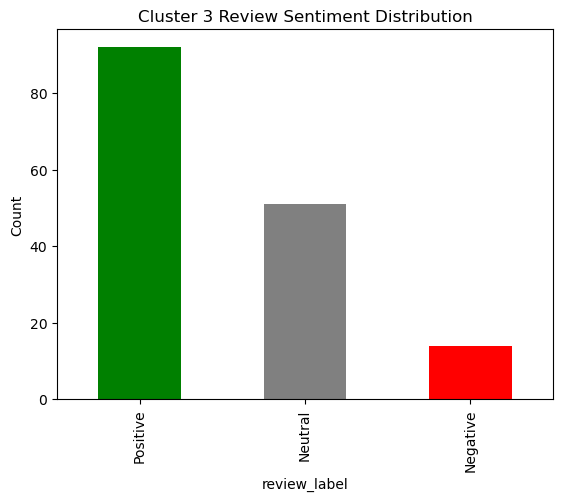

In [103]:
# plot
cluster3_scores['review_label'].value_counts().plot(
    kind='bar',
    color=['green', 'grey', 'red']
)

plt.title("Cluster 3 Review Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [104]:
#descriptive stat
cluster3_scores.describe()

,Review_Polarity,Summary_Polarity
count,157.000000,157.000000
mean,0.197493,0.181404
std,0.279449,0.326140
min,-0.500000,-0.500000
25%,0.023529,0.000000
50%,0.141667,0.004167
75%,0.340000,0.390000
max,1.000000,1.000000


### cluster 0

In [111]:
# filter out cluster 0
idx_list = [
16, 20, 28, 38, 66, 77, 81, 88, 93, 94,
112, 120, 216, 220, 228, 238, 266, 277, 281, 288,
293, 294, 312, 320, 416, 420, 428, 438, 466, 477,
481, 488, 493, 494, 512, 520, 616, 620, 628, 638,
666, 677, 681, 688, 693, 694, 712, 720, 816, 820,
828, 838, 866, 877, 881, 888, 893, 894, 912, 920,
1016, 1020, 1028, 1038, 1066, 1077, 1081, 1088, 1093, 1094,
1112, 1120, 1216, 1220, 1228, 1238, 1266, 1277, 1281, 1288,
1293, 1294, 1312, 1320, 1420, 1427, 1428, 1436, 1437, 1438,
1443, 1466, 1477, 1481, 1493, 1494, 1573, 1579, 1580, 1584,
1588, 1589, 1590, 1593, 1595, 1614, 1636, 1652, 1658, 1717,
1720, 1732, 1742, 1744, 1770, 1784, 1792, 1799, 1809, 1819,
1822, 1823, 1825, 1826, 1827, 1831, 1833, 1834, 1852, 1855,
1879, 1883, 1885, 1888, 1894, 1901, 1921, 1923, 1926, 1929,
1931, 1939, 1950, 1951, 1952, 1953, 1955, 1956, 1958, 1991
]
         

# extract sentiment scores
cluster0_scores = filtered.loc[idx_list, ['Review_Polarity', 'Summary_Polarity']]

# view results
print(cluster0_scores.head())

    Review_Polarity  Summary_Polarity
16         0.177288               0.7
20        -0.250000               0.0
28         0.541667               1.0
38         0.361296               0.0
66         0.166875               0.0


In [112]:
def label_sentiment(x):
    if x > 0.1:
        return "Positive"
    elif x < -0.1:
        return "Negative"
    else:
        return "Neutral"

cluster0_scores['review_label'] = cluster0_scores['Review_Polarity'].apply(label_sentiment)

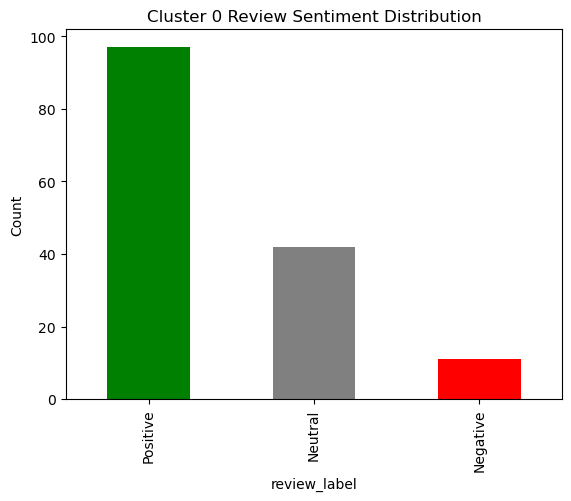

In [113]:
cluster0_scores['review_label'].value_counts().plot(
    kind='bar',
    color=['green', 'grey', 'red']
)

plt.title("Cluster 0 Review Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [115]:
cluster0_scores.describe()

,Review_Polarity,Summary_Polarity
count,150.000000,150.000000
mean,0.205206,0.218846
std,0.257636,0.335733
min,-0.400000,-0.400000
25%,0.050000,0.000000
50%,0.165580,0.075000
75%,0.300000,0.316071
max,1.000000,1.000000


### cluster 1

In [116]:
# cluster 1
idx_list = [
121, 124, 126, 132, 140, 142, 146, 176, 178,
321, 324, 326, 332, 340, 342, 346, 376, 378,
521, 524, 526, 532, 540, 542, 546, 576, 578,
721, 724, 726, 732, 740, 742, 746, 776, 778,
921, 924, 926, 932, 940, 942, 946, 976, 978,
1121, 1124, 1126, 1132, 1140, 1142, 1146, 1176, 1178,
1321, 1324, 1326, 1332, 1340, 1342, 1346, 1376, 1378,
1408, 1410, 1514, 1528, 1534, 1673, 1691, 1862
]

# extract sentiment scores
cluster1_scores = filtered.loc[idx_list, ['Review_Polarity', 'Summary_Polarity']]

# view results
print(cluster1_scores.head())

     Review_Polarity  Summary_Polarity
121         0.116071          0.500000
124        -0.106250          0.500000
126         0.148500          0.300000
132         0.466667          0.304167
140         0.318750          1.000000


In [117]:
def label_sentiment(x):
    if x > 0.1:
        return "Positive"
    elif x < -0.1:
        return "Negative"
    else:
        return "Neutral"

cluster1_scores['review_label'] = cluster1_scores['Review_Polarity'].apply(label_sentiment)

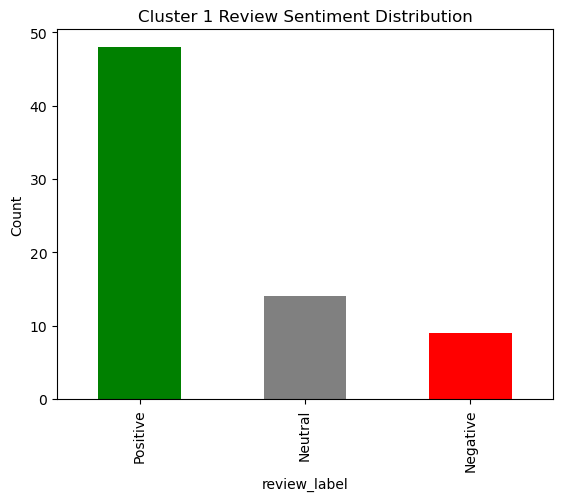

In [122]:
cluster1_scores['review_label'].value_counts().plot(
    kind='bar',
    color=['green', 'grey', 'red']
)

plt.title("Cluster 1 Review Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [125]:
cluster1_scores.describe()

,Review_Polarity,Summary_Polarity
count,71.000000,71.000000
mean,0.234155,0.258441
std,0.286328,0.326478
min,-0.275000,-0.650000
25%,0.067885,0.000000
50%,0.210101,0.200000
75%,0.378571,0.500000
max,1.000000,1.000000


### cluster 2

In [119]:
# cluster 2
idx_list = [
122, 133,
322, 333,
522, 533,
722, 733,
922, 933,
1122, 1133,
1322, 1333,
1507, 1511, 1519,
1672, 1682, 1690, 1702,
1867
]
# extract sentiment scores
cluster2_scores = filtered.loc[idx_list, ['Review_Polarity', 'Summary_Polarity']]

# view results
print(cluster2_scores.head())

     Review_Polarity  Summary_Polarity
122         0.227679               0.8
133        -0.040104               0.0
322        -0.048760               0.1
333         0.500000               0.0
522         0.000000               0.0


In [121]:
def label_sentiment(x):
    if x > 0.1:
        return "Positive"
    elif x < -0.1:
        return "Negative"
    else:
        return "Neutral"

cluster2_scores['review_label'] = cluster2_scores['Review_Polarity'].apply(label_sentiment)

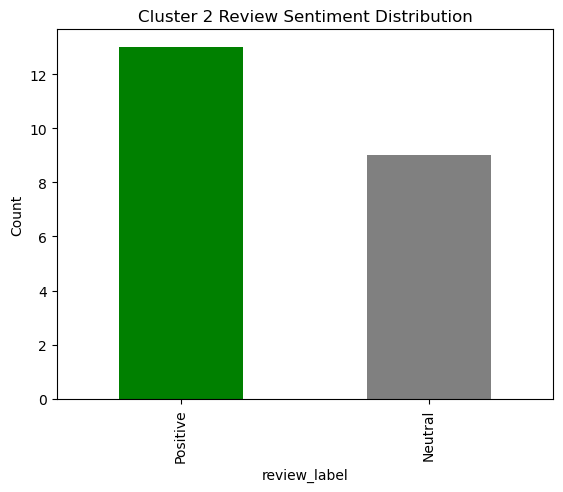

In [123]:
cluster2_scores['review_label'].value_counts().plot(
    kind='bar',
    color=['green', 'grey', 'red']
)

plt.title("Cluster 2 Review Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [124]:
cluster2_scores.describe()

,Review_Polarity,Summary_Polarity
count,22.000000,22.000000
mean,0.241456,0.204318
std,0.286928,0.300287
min,-0.095513,-0.100000
25%,0.000000,0.000000
50%,0.186163,0.000000
75%,0.359375,0.300000
max,1.000000,0.850000


### stat summary of the whole dataset
Review_Polarity  Summary_Polarity
count       400.000000        400.000000
mean          0.209311          0.210379
std           0.272513          0.328474
min          -0.500000         -0.650000
25%           0.039505          0.000000
50%           0.166130          0.050000
75%           0.335000          0.400000
max           1.000000          1.000000


### stat summary of all 4 groups
Review_Polarity	Summary_Polarity
count	2000.000000	2000.000000
mean	0.217702	0.219317
std	0.262489	0.335627
min	-1.000000	-1.000000
25%	0.049888	0.000000
50%	0.182258	0.062500
75%	0.361028	0.451250
max	1.000000	1.000000

# stat summary of the individual clusters
# marginal of cluster2
	Review_Polarity	Summary_Polarity
count	22.000000	22.000000
mean	0.241456	0.204318
std	0.286928	0.300287
min	-0.095513	-0.100000
25%	0.000000	0.000000
50%	0.186163	0.000000
75%	0.359375	0.300000
max	1.000000	0.850000

### marginal of cluster 0
Review_Polarity	Summary_Polarity
count	150.000000	150.000000
mean	0.205206	0.218846
std	0.257636	0.335733
min	-0.400000	-0.400000
25%	0.050000	0.000000
50%	0.165580	0.075000
75%	0.300000	0.316071
max	1.000000	1.000000

### marginal of cluster 1
Review_Polarity	Summary_Polarity
count	71.000000	71.000000
mean	0.234155	0.258441
std	0.286328	0.326478
min	-0.275000	-0.650000
25%	0.067885	0.000000
50%	0.210101	0.200000
75%	0.378571	0.500000
max	1.000000	1.000000

# marginal of cluster 3
Review_Polarity	Summary_Polarity
count	157.000000	157.000000
mean	0.197493	0.181404
std	0.279449	0.326140
min	-0.500000	-0.500000
25%	0.023529	0.000000
50%	0.141667	0.004167
75%	0.340000	0.390000
max	1.000000	1.000000


Customers are not forming strongly different sentiment groups; instead, they generally express mild sentiment, with a small number of extreme positive and negative outliers. Therefore, sentiment alone does not clearly explain why these customers fall at the cluster margins. This is likely because the K-means clustering was based on income and spending score, while sentiment represents a different dimension of customer behaviour.